<a href="https://colab.research.google.com/github/ridahafeez786/AI_Bootcamp_Lab-work/blob/main/transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformer From Scratch

Implements the basics of **Attention Is All You Need** architecture using PyTorch.
![Attention Research](https://machinelearningmastery.com/wp-content/uploads/2021/08/attention_research_1.png)


In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.utils.data import Dataset, DataLoader
from collections import Counter


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
'''
def load_dataset():
    with open('english-corpus.txt','r',encoding='utf8') as f:
        english = f.read().splitlines()

    with open('urdu-corpus.txt','r',encoding='utf8') as f:
        urdu = f.read().splitlines()

    pairs = list(zip(english, urdu))
    print("Total sentence pairs:", len(pairs))
    return pairs
'''

'\ndef load_dataset():\n    with open(\'english-corpus.txt\',\'r\',encoding=\'utf8\') as f:\n        english = f.read().splitlines()\n\n    with open(\'urdu-corpus.txt\',\'r\',encoding=\'utf8\') as f:\n        urdu = f.read().splitlines()\n\n    pairs = list(zip(english, urdu))\n    print("Total sentence pairs:", len(pairs))\n    return pairs\n'

In [ ]:
def load_dataset():
    english_path = "/content/drive/MyDrive/Bootcamp/english-corpus.txt"
    urdu_path = "/content/drive/MyDrive/Bootcamp/urdu-corpus.txt"

    with open(english_path, "r", encoding="utf-8") as f:
        english = f.read().splitlines()

    with open(urdu_path, "r", encoding="utf-8") as f:
        urdu = f.read().splitlines()

    pairs = list(zip(english, urdu))
    print("Total sentence pairs:", len(pairs))
    return pairs

# Load dataset
pairs = load_dataset()

Total sentence pairs: 24525


In [ ]:
pairs[0:5]

[('is zain your nephew', 'زین تمہارا بھتیجا ہے۔'),
 ('i wish youd trust me', 'کاش تم مجھ پر بھروسہ کرتے'),
 ('did he touch you', 'کیا اس نے آپ کو چھوا؟'),
 ('its part of life', 'اس کی زندگی کا حصہ'),
 ('zain isnt ugly', 'زین بدصورت نہیں ہے۔')]

**Tokenizer**

In [ ]:

def tokenize(sentence):
    return sentence.lower().split()
# in pretained transformer we gave subword BPE tokenizers and improved++


**Vocabulary Class**

In [ ]:

class Vocabulary:

    def __init__(self):
        self.word2idx = {"<pad>":0,"<sos>":1,"<eos>":2,"<unk>":3}
        self.idx2word = {0:"<pad>",1:"<sos>",2:"<eos>",3:"<unk>"}

    def build_vocab(self, sentences):
        idx = 4
        for sentence in sentences:
            for word in tokenize(sentence):
                if word not in self.word2idx:
                    self.word2idx[word] = idx
                    self.idx2word[idx] = word
                    idx += 1

    def numericalize(self, sentence):
        return [self.word2idx.get(word,3) for word in tokenize(sentence)]


**Build Vocabulary**

In [ ]:

pairs = load_dataset()

src_sentences = [p[0] for p in pairs]
trg_sentences = [p[1] for p in pairs]

src_vocab = Vocabulary()
trg_vocab = Vocabulary()

src_vocab.build_vocab(src_sentences)
trg_vocab.build_vocab(trg_sentences)

print("English vocab:", len(src_vocab.word2idx))
print("Urdu vocab:", len(trg_vocab.word2idx))


Total sentence pairs: 24525
English vocab: 5770
Urdu vocab: 5988


In [ ]:

print("English vocab:", src_vocab.word2idx)
print("Urdu vocab:", trg_vocab.word2idx)

English vocab: {'<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3, 'is': 4, 'zain': 5, 'your': 6, 'nephew': 7, 'i': 8, 'wish': 9, 'youd': 10, 'trust': 11, 'me': 12, 'did': 13, 'he': 14, 'touch': 15, 'you': 16, 'its': 17, 'part': 18, 'of': 19, 'life': 20, 'isnt': 21, 'ugly': 22, 'above': 23, 'all': 24, 'be': 25, 'patient': 26, 'learned': 27, 'it': 28, 'from': 29, 'him': 30, 'why': 31, 'am': 32, 'doing': 33, 'this': 34, 'made': 35, 'a': 36, 'bad': 37, 'decision': 38, 'wont': 39, 'care': 40, 'was': 41, 'hesitant': 42, 'borrowed': 43, 'zains': 44, 'car': 45, 'are': 46, 'out': 47, 'here': 48, 'just': 49, 'liar': 50, 'were': 51, 'almost': 52, 'done': 53, 'what': 54, 'happening': 55, 'betrayed': 56, 'us': 57, 'goofed': 58, 'everythings': 59, 'fine': 60, 'for': 61, 'give': 62, 'that': 63, 'come': 64, 'on': 65, 'wake': 66, 'up': 67, 'needs': 68, 'the': 69, 'ladder': 70, 'not': 71, 'tired': 72, 'yet': 73, 'very': 74, 'full': 75, 'energy': 76, 'have': 77, 'got': 78, 'no': 79, 'worries': 80, 'wheres'

In [ ]:
print("Urdu vocab:", trg_vocab.idx2word)

Urdu vocab: {0: '<pad>', 1: '<sos>', 2: '<eos>', 3: '<unk>', 4: 'زین', 5: 'تمہارا', 6: 'بھتیجا', 7: 'ہے۔', 8: 'کاش', 9: 'تم', 10: 'مجھ', 11: 'پر', 12: 'بھروسہ', 13: 'کرتے', 14: 'کیا', 15: 'اس', 16: 'نے', 17: 'آپ', 18: 'کو', 19: 'چھوا؟', 20: 'کی', 21: 'زندگی', 22: 'کا', 23: 'حصہ', 24: 'بدصورت', 25: 'نہیں', 26: 'سب', 27: 'سے', 28: 'بڑھ', 29: 'کر', 30: 'صبر', 31: 'کرو', 32: 'میں', 33: 'اسے', 34: 'سیکھا۔', 35: 'یہ', 36: 'کیوں', 37: 'رہا', 38: 'ہوں', 39: 'ایک', 40: 'برا', 41: 'فیصلہ', 42: 'پرواہ', 43: 'کرے', 44: 'گا', 45: 'ہچکچا', 46: 'تھا', 47: 'گاڑی', 48: 'ادھار', 49: 'لی', 50: 'یہاں', 51: 'باہر', 52: 'ہو', 53: 'وہ', 54: 'صرف', 55: 'جھوٹا', 56: 'تقریباً', 57: 'گیا', 58: 'ہے', 59: 'آج', 60: 'کل', 61: 'ہمیں', 62: 'دھوکہ', 63: 'دیا۔', 64: 'بیوقوف', 65: 'ٹھیک', 66: 'کے', 67: 'لیے', 68: 'ہے؟', 69: 'تمہیں', 70: 'دیا', 71: 'آؤ', 72: 'اٹھو', 73: 'سیڑھی', 74: 'ضرورت', 75: 'ابھی', 76: 'تک', 77: 'تھکا', 78: 'بہت', 79: 'ہوا', 80: 'توانائی', 81: 'بھرا', 82: 'مجھے', 83: 'کوئی', 84: 'پریشانی', 85: 'میرا

**Dataset**

In [ ]:

class TranslationDataset(Dataset):

    def __init__(self,pairs,src_vocab,trg_vocab):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self,idx):
        src,trg = self.pairs[idx]

        src = [1] + self.src_vocab.numericalize(src) + [2]
        trg = [1] + self.trg_vocab.numericalize(trg) + [2]

        return torch.tensor(src),torch.tensor(trg)


**Padding**

In [ ]:

def collate(batch):
    src_batch=[]
    trg_batch=[]

    for src,trg in batch:
        src_batch.append(src)
        trg_batch.append(trg)

    src_batch = nn.utils.rnn.pad_sequence(src_batch,batch_first=True,padding_value=0)
    trg_batch = nn.utils.rnn.pad_sequence(trg_batch,batch_first=True,padding_value=0)

    return src_batch,trg_batch


**DataLoader**

In [ ]:

dataset = TranslationDataset(pairs,src_vocab,trg_vocab)
loader = DataLoader(dataset,batch_size=32,shuffle=True,collate_fn=collate)


In [ ]:
dataset[10]

(tensor([ 1,  5, 41, 42,  2]), tensor([ 1,  4, 45, 37, 46,  2]))

In [ ]:
# Get an iterator from the DataLoader
data_iter = iter(loader)

# Get the first batch
batch = next(data_iter)

# Display the batch
print(batch)

# Or display individual components if batch is a tuple/dict
# For a typical translation dataset, batch might contain (src_batch, trg_batch)
src_batch, trg_batch = batch
print(f"Source batch shape: {src_batch.shape}")
print(f"Target batch shape: {trg_batch.shape}")
print(f"Source batch:\n{src_batch}")
print(f"Target batch:\n{trg_batch}")

(tensor([[   1,  105,   69,  630,    2,    0,    0,    0],
        [   1,  185,   12,  353,    2,    0,    0,    0],
        [   1,   14,  303,  150,  657,   16,    2,    0],
        [   1,   34,   41,   79,  500,    2,    0,    0],
        [   1,  125,  165,  718,  514,    2,    0,    0],
        [   1,    5,    4, 4793,    2,    0,    0,    0],
        [   1,   16, 1808,   82,  158,    2,    0,    0],
        [   1,  526,    6, 1117,    2,    0,    0,    0],
        [   1,    5,    4,   91,    2,    0,    0,    0],
        [   1,   14,  381,   36,  518,  482,    2,    0],
        [   1,  118,  244,  150,   82,  692,    2,    0],
        [   1,   97,   25,  365, 3259,    2,    0,    0],
        [   1,   14,   27,  150,  977,    2,    0,    0],
        [   1,   34,    4,  338,    8,  204,    2,    0],
        [   1,   17,   36,  265,   19,  266,    2,    0],
        [   1,  437,  125,   16,   11,    2,    0,    0],
        [   1,    8,  191, 2686,    2,    0,    0,    0],
        [   1

In [ ]:
data_iter = iter(loader)

# Display first 3 batches
for i in range(3):
    batch = next(data_iter)
    print(f"\n--- Batch {i+1} ---")
    print(batch)


--- Batch 1 ---
(tensor([[   1,    5,  277,   24,  916,    2,    0,    0],
        [   1,   17,   18,   19,   82,  752,    2,    0],
        [   1,    5, 2635,  221,   67,    2,    0,    0],
        [   1,   51,  112,   69,  356,    2,    0,    0],
        [   1, 1083,  217,   28,  943,    2,    0,    0],
        [   1,   54,   41,   69,  770,    2,    0,    0],
        [   1,  617,   63,  397, 1827,    2,    0,    0],
        [   1,   14,    4, 1537,  333,  393,    2,    0],
        [   1,    8,   97,  286, 1080,    2,    0,    0],
        [   1, 1533,    6, 4476,    2,    0,    0,    0],
        [   1,   54, 1393,  617,   28,  397,    2,    0],
        [   1,    8,  107,   16,   46, 1532,    2,    0],
        [   1, 3797,   69, 2327,    2,    0,    0,    0],
        [   1,  131,   16,  386, 1136,    2,    0,    0],
        [   1,    8,   32,  310,   19, 1396,    2,    0],
        [   1,    8,   13,  287,    8,   41,  172,    2],
        [   1,  142,   95,  424,  316,    2,    0,    

**Positional Encoding**

In [ ]:
import matplotlib.pyplot as plt
class PositionalEncoding(nn.Module):

    def __init__(self,d_model,max_len=500):#5000
        super().__init__()
        pe = torch.zeros(max_len,d_model)
        position = torch.arange(0,max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0,d_model,2)*(-math.log(10000)/d_model))

        pe[:,0::2] = torch.sin(position*div_term)
        pe[:,1::2] = torch.cos(position*div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe",pe)
        """
        important PyTorch feature.

        A buffer stored inside the model,not trained,saved with the model So positional encoding stays fixed.
        """

    def forward(self,x):
        return x + self.pe[:,:x.size(1)]


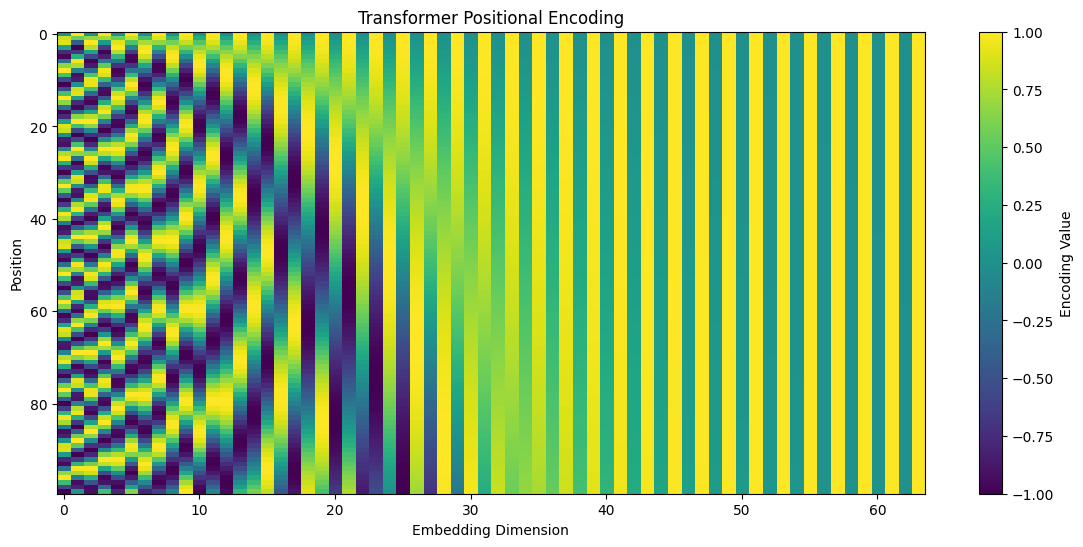

In [ ]:
import matplotlib.pyplot as plt
import torch

d_model = 64
max_len = 100

pe = PositionalEncoding(d_model=d_model, max_len=max_len)

plt.figure(figsize=(14,6))
plt.imshow(pe.pe[0].numpy(), cmap='viridis', aspect='auto')
plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.title("Transformer Positional Encoding")
plt.colorbar(label="Encoding Value")
plt.show()

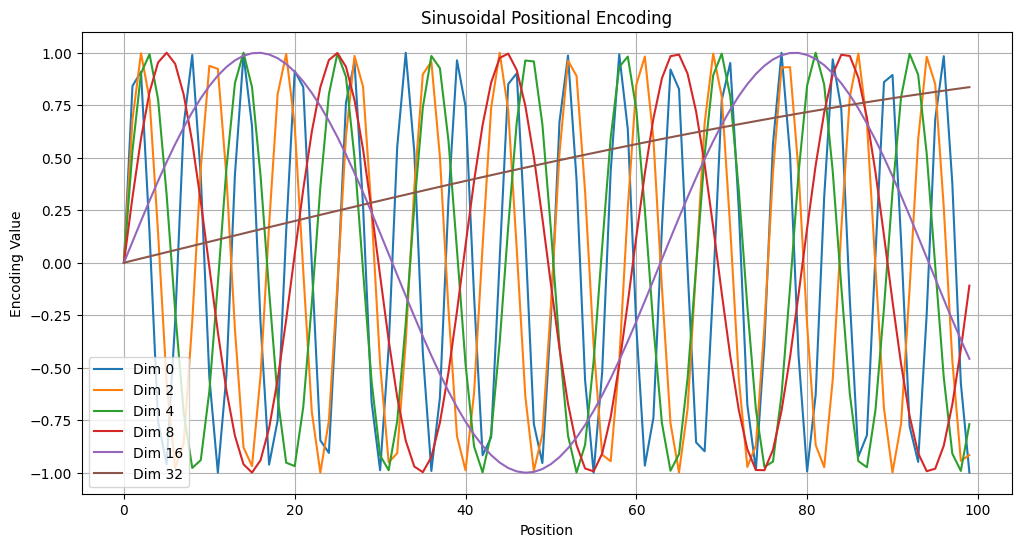

In [ ]:
plt.figure(figsize=(12,6))

for dim in [0, 2, 4, 8, 16, 32]:
    plt.plot(pe.pe[0, :, dim].numpy(), label=f"Dim {dim}")

plt.xlabel("Position")
plt.ylabel("Encoding Value")
plt.title("Sinusoidal Positional Encoding")
plt.legend()
plt.grid(True)
plt.show()

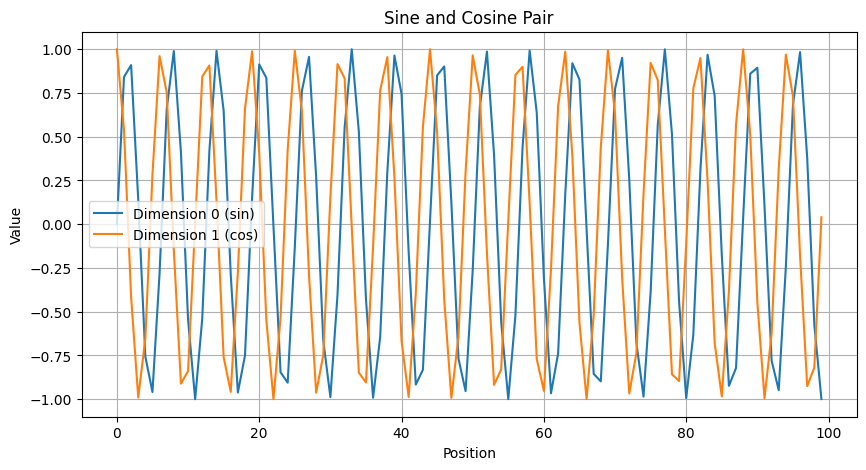

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(pe.pe[0,:,0].numpy(), label="Dimension 0 (sin)")
plt.plot(pe.pe[0,:,1].numpy(), label="Dimension 1 (cos)")

plt.xlabel("Position")
plt.ylabel("Value")
plt.title("Sine and Cosine Pair")
plt.legend()
plt.grid(True)
plt.show()

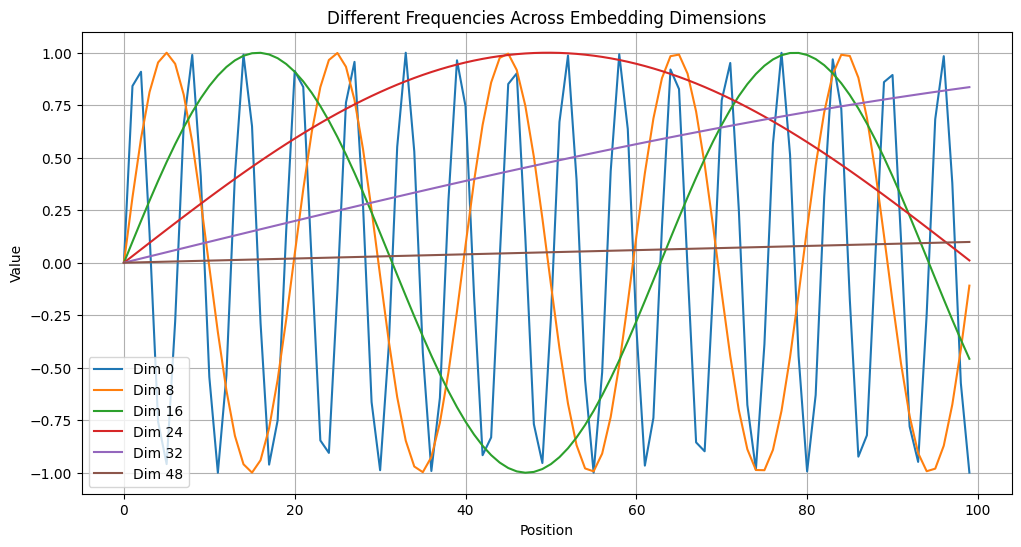

In [ ]:
plt.figure(figsize=(12,6))

dims = [0, 8, 16, 24, 32, 48]

for d in dims:
    plt.plot(pe.pe[0,:,d].numpy(), label=f"Dim {d}")

plt.legend()
plt.grid(True)
plt.xlabel("Position")
plt.ylabel("Value")
plt.title("Different Frequencies Across Embedding Dimensions")
plt.show()

**Multi-Head Attention**

| Component | Meaning                  |
| --------- | ------------------------ |
| Query     | what you are looking for |
| Key       | labels of books          |
| Value     | content of books         |


In [ ]:

class MultiHeadAttention(nn.Module):

    def __init__(self,d_model=100,heads=2):#model=512,head=8
        super().__init__()
        self.heads = heads
        self.head_dim = d_model//heads

        self.q = nn.Linear(d_model,d_model)#XWq-Transforms input embedding into query vectors.
        self.k = nn.Linear(d_model,d_model)#XWk-represent information each word contains.
        self.v = nn.Linear(d_model,d_model)#VWv-actual information passed to the next layer.

        self.fc = nn.Linear(d_model,d_model)

    def forward(self,q,k,v,mask=None):

        B = q.shape[0]#q shape = (32,10,100)

        Q = self.q(q)
        K = self.k(k)
        V = self.v(v)
#(B, seq_len, heads, head_dim),(32,10,2,50) then transpose final shape becomes(32,2,10,50)
        #each head process own attention
        Q = Q.view(B,-1,self.heads,self.head_dim).transpose(1,2)
        K = K.view(B,-1,self.heads,self.head_dim).transpose(1,2)
        V = V.view(B,-1,self.heads,self.head_dim).transpose(1,2)

        scores = torch.matmul(Q,K.transpose(-2,-1))/math.sqrt(self.head_dim)

        if mask is not None:
            scores = scores.masked_fill(mask==0,-1e9)

        attention = torch.softmax(scores,-1)

        out = torch.matmul(attention,V)

        out = out.transpose(1,2).contiguous().view(B,-1,self.heads*self.head_dim)

        return self.fc(out)


| Code        | Mathematical Meaning | Output Shape |
| ----------- | -------------------- | ------------ |
| Q=self.q(q) | XWq                  | (32,10,100)  |
| K=self.k(k) | XWk                  | (32,10,100)  |
| V=self.v(v) | XWv                  | (32,10,100)  |
| view        | Split heads          | (32,10,2,50) |
| transpose   | Move head dimension  | (32,2,10,50) |
| matmul      | QKᵀ                  | (32,2,10,10) |
| softmax     | Attention weights    | (32,2,10,10) |
| matmul(V)   | Weighted values      | (32,2,10,50) |
| merge       | Combine heads        | (32,10,100)  |


**Feed Forward**

In [ ]:
class FeedForward(nn.Module):

    def __init__(self,d_model=100,hidden=50):#moedl-512,hidden=2048
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(d_model,hidden),
            nn.ReLU(),
            nn.Linear(hidden,d_model)
        )

    def forward(self,x):
        return self.net(x)

**Encoder Layer**

In [ ]:
class EncoderLayer(nn.Module):

    def __init__(self,d_model=100,heads=2):
        super().__init__()

        self.att = MultiHeadAttention(d_model,heads)
        self.norm1 = nn.LayerNorm(d_model)

        self.ff = FeedForward(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self,x,mask):
        x = self.norm1(x + self.att(x,x,x,mask))
        x = self.norm2(x + self.ff(x))
        return x

**Decoder Layer**

In [ ]:

class DecoderLayer(nn.Module):

    def __init__(self,d_model=100,heads=2):
        super().__init__()

        self.self_att = MultiHeadAttention(d_model,heads)
        self.norm1 = nn.LayerNorm(d_model)

        self.cross_att = MultiHeadAttention(d_model,heads)
        self.norm2 = nn.LayerNorm(d_model)

        self.ff = FeedForward(d_model)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self,x,enc_out,src_mask,trg_mask):

        x = self.norm1(x + self.self_att(x,x,x,trg_mask))

        x = self.norm2(x + self.cross_att(x,enc_out,enc_out,src_mask))

        x = self.norm3(x + self.ff(x))

        return x


**Encoder **

In [ ]:
class Encoder(nn.Module):

    def __init__(self,vocab_size,d_model=100,layers=2):#layers-6
        super().__init__()

        self.embed = nn.Embedding(vocab_size,d_model)
        self.pos = PositionalEncoding(d_model)

        self.layers = nn.ModuleList([EncoderLayer() for _ in range(layers)])

    def forward(self,x,mask):

        x = self.embed(x)
        x = self.pos(x)

        for layer in self.layers:
            x = layer(x,mask)

        return x

**Decoder**

In [ ]:
class Decoder(nn.Module):

    def __init__(self,vocab_size,d_model=100,layers=2):#layer 6
        super().__init__()

        self.embed = nn.Embedding(vocab_size,d_model)
        self.pos = PositionalEncoding(d_model)

        self.layers = nn.ModuleList([DecoderLayer() for _ in range(layers)])

        self.fc = nn.Linear(d_model,vocab_size)

    def forward(self,x,enc_out,src_mask,trg_mask):

        x = self.embed(x)
        x = self.pos(x)

        for layer in self.layers:
            x = layer(x,enc_out,src_mask,trg_mask)

        return self.fc(x)

**Transformer**

In [ ]:
class Transformer(nn.Module):

    def __init__(self,src_vocab,trg_vocab):
        super().__init__()

        self.encoder = Encoder(src_vocab)
        self.decoder = Decoder(trg_vocab)

    def make_src_mask(self,src):
        return (src!=0).unsqueeze(1).unsqueeze(2)

    def make_trg_mask(self,trg):

        L = trg.shape[1]

        mask = torch.tril(torch.ones(L,L)).expand(trg.shape[0],1,L,L)

        return mask

    def forward(self,src,trg):

        src_mask = self.make_src_mask(src)
        trg_mask = self.make_trg_mask(trg)

        enc = self.encoder(src,src_mask)

        out = self.decoder(trg,enc,src_mask,trg_mask)

        return out

| Attention       | Query   | Key     | Value   |
| --------------- | ------- | ------- | ------- |
| Encoder Self    | source  | source  | source  |
| Masked Decoder  | target  | target  | target  |
| Cross Attention | decoder | encoder | encoder |


**Training**

In [ ]:
model = Transformer(len(src_vocab.word2idx),len(trg_vocab.word2idx))

optimizer = optim.Adam(model.parameters(),lr=0.0003)

criterion = nn.CrossEntropyLoss(ignore_index=0)

for epoch in range(2):

    for src,trg in loader:

        output = model(src,trg[:,:-1]) #decoder input removing eos

        output = output.reshape(-1,output.shape[-1])
        target = trg[:,1:].reshape(-1)

        loss = criterion(output,target)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    print("Epoch",epoch,"Loss",loss.item())

Epoch 0 Loss 4.033123016357422
Epoch 1 Loss 2.9416520595550537


**Translation**

In [ ]:
def translate(sentence):

    model.eval()

    tokens = [1] + src_vocab.numericalize(sentence) + [2]

    src = torch.tensor(tokens).unsqueeze(0)

    trg = torch.tensor([[1]])

    for i in range(20):

        out = model(src, trg)

        next_word = out.argmax(-1)[:, -1].item()

        trg = torch.cat([trg, torch.tensor([[next_word]])], dim=1)

        if next_word == 2:
            break

    words = [trg_vocab.idx2word[i.item()] for i in trg[0]]

    return " ".join(words)


print(translate("I am good"))

<sos> میں اچھا ہوں <eos>


In [ ]:
import torch

A = torch.ones(4,4)

print(A)

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])


In [ ]:
torch.tril(A)

tensor([[1., 0., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 1., 0.],
        [1., 1., 1., 1.]])

# Practical: Use a pretrained Hugging Face MarianMT model for real translation

In [ ]:
# Install required libraries
!pip install transformers torch

In [ ]:
from transformers import MarianMTModel, MarianTokenizer
def load_model():
    model_name = 'Helsinki-NLP/opus-mt-en-ur'  # English to Urdu
    print('Loading pretrained model (PyTorch)...')
    tokenizer = MarianTokenizer.from_pretrained(model_name)
    model = MarianMTModel.from_pretrained(model_name)
    return tokenizer, model

tokenizer, model = load_model()

Loading pretrained model (PyTorch)...


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/816k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/848k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  306MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Translation function + input handling (takes tokenizer and model as input)

In [ ]:
# 2. Translation function
def translate_en_to_tr(sentences, tokenizer, model):
    inputs = tokenizer(sentences, return_tensors="pt", padding=True, truncation=True)
    generated = model.generate(**inputs)
    translations = [tokenizer.decode(g, skip_special_tokens=True) for g in generated]
    return translations

**Way One**

In [ ]:
# 3. Quick check
src_texts = [
    "I love deep learning.",
    "She likes cats and dogs.",
    "Machine translation is amazing."
]
print("Source texts:", src_texts)

try:
    translated = translate_en_to_tr(src_texts, tokenizer, model)
    for src, trans in zip(src_texts, translated):
        print(f"EN: {src}\nUR: {trans}\n")
except Exception as e:
    print("Failed to decode or print translations:", e)

Source texts: ['I love deep learning.', 'She likes cats and dogs.', 'Machine translation is amazing.']
EN: I love deep learning.
UR: مَیں گہری سیکھنے سے محبت کرتی ہوں ۔

EN: She likes cats and dogs.
UR: وہ کتے اور کتے جیسی ہوتی ہے ۔

EN: Machine translation is amazing.
UR: وکی ترجمے حیرت انگیز ہے.



**Gradio Simulation**

In [ ]:
# 4. Gradio interface
import gradio as gr
def gradio_translate(input_text):
    # Split multiple sentences by '|'
    sentences = [s.strip() for s in input_text.split('|') if s.strip()]
    if not sentences:
        return "Please enter at least one sentence."
    translations = translate_en_to_tr(sentences, tokenizer, model)
    result = ""
    for en, ur in zip(sentences, translations):
        result += f"ENG: {en}\nUrdu: {ur}\n\n"
    return result.strip()

iface = gr.Interface(
    fn=gradio_translate,
    inputs=gr.Textbox(lines=3, placeholder="Enter English sentence(s), separate multiple with |"),
    outputs="text",
    title="English to Urdu Translation",
    description="Translate English sentences to Urdu using a pretrained Transformer model."
)

iface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://43850aef686c2fffb5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://43850aef686c2fffb5.gradio.live
